# Decision Trees: From Intuition to Implementation

---

## Why Decision Trees?

Decision trees are among the most **interpretable** machine learning models available. Unlike black-box models where predictions emerge from opaque computations, a decision tree's logic can be traced step by step making it invaluable when you need to **explain** your model's reasoning.

**What makes them stand out:**
- **Transparent reasoning** - you can visualize exactly how predictions are made
- **No feature scaling required** - they work directly with raw data
- **Natural handling of non-linear relationships**
- **Support for both numerical and categorical features**
- **Applicable to classification and regression tasks**

In [1]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.datasets import load_iris, load_wine, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pandas as pd

plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

Matplotlib is building the font cache; this may take a moment.


## Motivation: Will a Customer Churn?

Imagine you work at a telecom company and want to predict whether a customer will **cancel their subscription** (churn). You have data about customers including:
- Monthly charges
- Contract length
- Customer tenure

Your goal: build a model that outputs **STAY** or **CHURN** for each customer.

### A Simple Rule

**Feature: Monthly Charges**
- Customers paying more than €70/month might be at higher risk of churning

We can represent this as a simple flowchart:

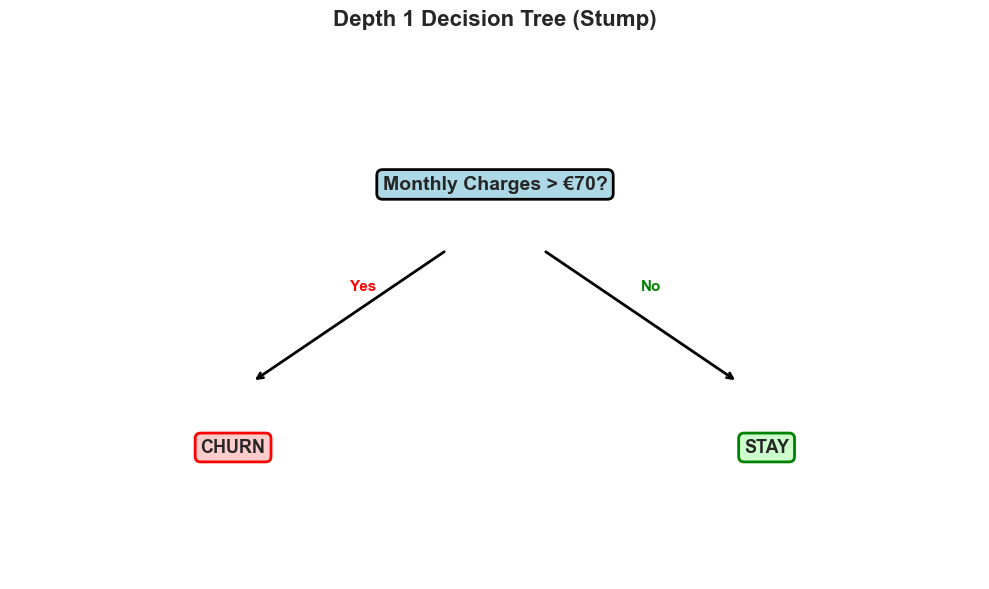


🌲 This is a decision stump (depth 1 tree)!
   • Root node: Tests monthly charges
   • Two leaf nodes: CHURN or STAY predictions


In [2]:
# Visualize a simple decision tree concept
fig, ax = plt.subplots(figsize=(10, 6))

# Root node
ax.text(0.5, 0.9, 'Monthly Charges > €70?', ha='center', va='center',
       bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='black', linewidth=2),
       fontsize=14, fontweight='bold')

# Branches
ax.annotate('', xy=(0.25, 0.75), xytext=(0.45, 0.85),
           arrowprops=dict(arrowstyle='->', lw=2, color='black'))
ax.annotate('', xy=(0.75, 0.75), xytext=(0.55, 0.85),
           arrowprops=dict(arrowstyle='->', lw=2, color='black'))

# Labels on branches
ax.text(0.35, 0.82, 'Yes', fontsize=11, fontweight='bold', color='red')
ax.text(0.65, 0.82, 'No', fontsize=11, fontweight='bold', color='green')

# Leaf nodes
ax.text(0.23, 0.7, 'CHURN', ha='center', va='center',
       bbox=dict(boxstyle='round', facecolor='#ffcccc', edgecolor='red', linewidth=2),
       fontsize=13, fontweight='bold')
ax.text(0.78, 0.7, 'STAY', ha='center', va='center',
       bbox=dict(boxstyle='round', facecolor='#ccffcc', edgecolor='green', linewidth=2),
       fontsize=13, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(0.6, 1)
ax.axis('off')
ax.set_title('Depth 1 Decision Tree (Stump)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🌲 This is a decision stump (depth 1 tree)!")
print("   • Root node: Tests monthly charges")
print("   • Two leaf nodes: CHURN or STAY predictions")

## Adding More Decision Layers

A single rule is too simplistic. We're ignoring valuable information!

**Additional Feature: Contract Type**
- Month-to-month contracts are easier to cancel than annual ones

By adding another level, we can capture more nuanced patterns. Notice how with this deeper tree, a customer paying >€70 might still STAY if they have a long-term contract!

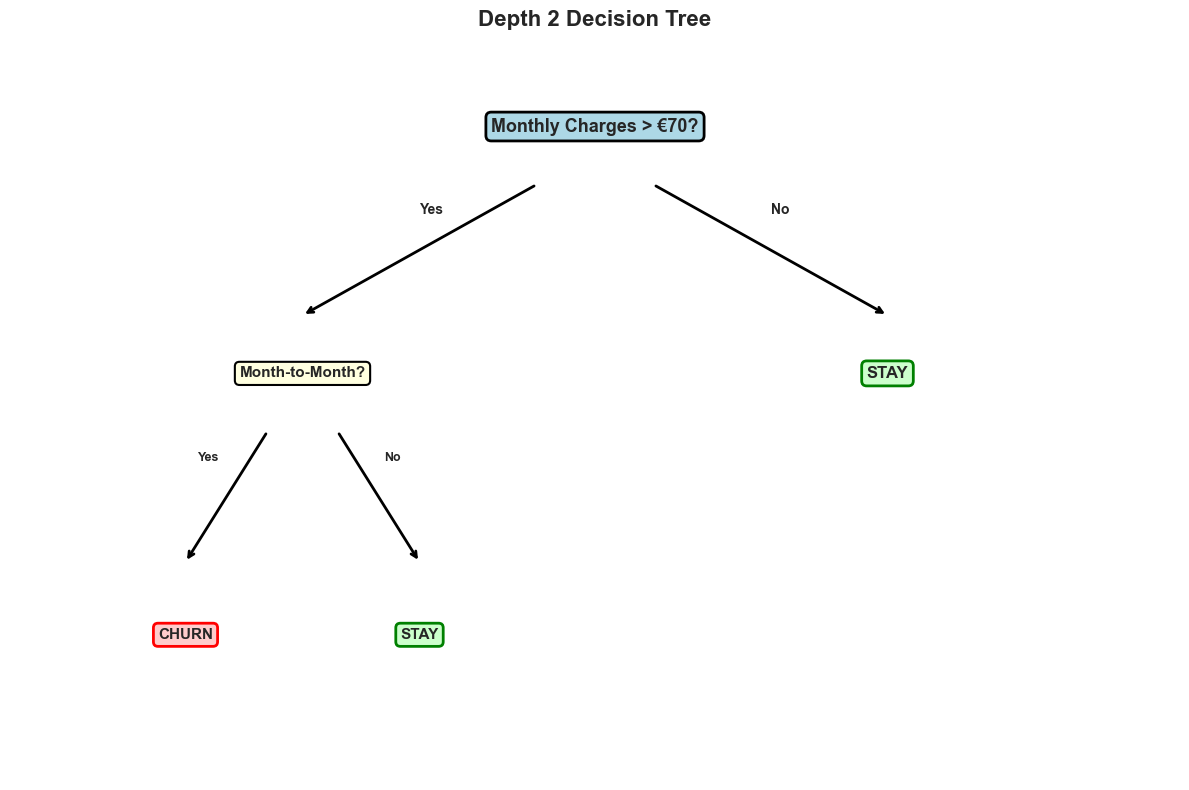


🌳 Now we have a depth 2 tree!
   • High charges + month-to-month contract → CHURN
   • High charges + annual contract → STAY
   • The tree captures conditional relationships


In [3]:
# Visualize a deeper tree
fig, ax = plt.subplots(figsize=(12, 8))

# Root
ax.text(0.5, 0.95, 'Monthly Charges > €70?', ha='center', va='center',
       bbox=dict(boxstyle='round', facecolor='lightblue', edgecolor='black', linewidth=2),
       fontsize=13, fontweight='bold')

# Level 1 branches
ax.annotate('', xy=(0.25, 0.82), xytext=(0.45, 0.91),
           arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(0.75, 0.82), xytext=(0.55, 0.91),
           arrowprops=dict(arrowstyle='->', lw=2))
ax.text(0.35, 0.89, 'Yes', fontsize=10, fontweight='bold')
ax.text(0.65, 0.89, 'No', fontsize=10, fontweight='bold')

# Level 1 nodes
ax.text(0.25, 0.78, 'Month-to-Month?', ha='center', va='center',
       bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='black', linewidth=1.5),
       fontsize=11, fontweight='bold')
ax.text(0.75, 0.78, 'STAY', ha='center', va='center',
       bbox=dict(boxstyle='round', facecolor='#ccffcc', edgecolor='green', linewidth=2),
       fontsize=12, fontweight='bold')

# Level 2 branches
ax.annotate('', xy=(0.15, 0.65), xytext=(0.22, 0.74),
           arrowprops=dict(arrowstyle='->', lw=2))
ax.annotate('', xy=(0.35, 0.65), xytext=(0.28, 0.74),
           arrowprops=dict(arrowstyle='->', lw=2))
ax.text(0.16, 0.72, 'Yes', fontsize=9, fontweight='bold')
ax.text(0.32, 0.72, 'No', fontsize=9, fontweight='bold')

# Leaf nodes
ax.text(0.15, 0.6, 'CHURN', ha='center', va='center',
       bbox=dict(boxstyle='round', facecolor='#ffcccc', edgecolor='red', linewidth=2),
       fontsize=11, fontweight='bold')
ax.text(0.35, 0.6, 'STAY', ha='center', va='center',
       bbox=dict(boxstyle='round', facecolor='#ccffcc', edgecolor='green', linewidth=2),
       fontsize=11, fontweight='bold')

ax.set_xlim(0, 1)
ax.set_ylim(0.5, 1)
ax.axis('off')
ax.set_title('Depth 2 Decision Tree', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🌳 Now we have a depth 2 tree!")
print("   • High charges + month-to-month contract → CHURN")
print("   • High charges + annual contract → STAY")
print("   • The tree captures conditional relationships")

## Anatomy of a Decision Tree

Decision trees have a **hierarchical structure**:

- **Root node** - The first decision point (top of the tree)
- **Internal nodes** - Intermediate decision points that test a feature
- **Branches** - Outcomes of each test (typically binary: Yes/No)
- **Leaf nodes** - Terminal nodes containing the final prediction

### Core Properties

1. Each internal node selects a **feature** and a **threshold** for splitting
2. Data flows down based on whether the condition is satisfied
3. Leaf nodes output a **class label** (classification) or **value** (regression)
4. Trees are visualized "upside down" (root at top)

### The Interpretability Advantage

Making a prediction is straightforward:
1. Start at the root
2. Evaluate each condition as you traverse down
3. The leaf you reach contains your prediction

This transparency is why decision trees are popular in regulated industries (finance, healthcare) where model explainability is required.

**But here's the challenge:** How do we decide *which* feature to split on at each node?

## The Computational Challenge of Tree Building

Here's a sobering fact: **finding the optimal decision tree is NP-complete**.

What does this mean practically?
- With $n$ features and $m$ possible thresholds, the search space explodes combinatorially
- For any reasonably-sized dataset, exhaustively searching all possible trees is computationally not feasible

### The Greedy Solution

Instead of searching for the globally optimal tree, we use a **greedy algorithm**:
- At each node, select the **locally best split** based on some criterion
- This doesn't guarantee the best possible tree, but gives us good results efficiently

The key question becomes: **what makes a split "good"?**

## Measuring Split Quality: Entropy and Information Gain

The most common approach uses **information gain**, which builds on the concept of **entropy** from information theory.

### Entropy: Measuring Impurity

Entropy quantifies the "disorder" or "uncertainty" in a set of labels:

$$
\text{Entropy}(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)
$$

Where $p_i$ is the proportion of samples belonging to class $i$.

**Intuition:**
- **High entropy** → Labels are mixed (high uncertainty)  
- **Low entropy** → Labels are mostly homogeneous (low uncertainty)  
- **Zero entropy** → All samples have the same label (perfect purity)

### Example: Customer Churn Dataset

Suppose we have 100 customers:  
- 65 **stayed** (STAY)  
- 35 **churned** (CHURN)

**Initial entropy** (before any split):

$$
\text{Entropy}(S) = -\frac{65}{100}\log_2\left(\frac{65}{100}\right) - \frac{35}{100}\log_2\left(\frac{35}{100}\right) \approx 0.934
$$

This is close to maximum entropy (which would be 1.0 for a 50-50 split), indicating significant uncertainty.

---

## Gini Index

An alternative impurity measure used in decision trees is the **Gini index** (also called **Gini impurity**).

### Definition

$$
\text{Gini}(S) = 1 - \sum_{i=1}^{c} p_i^2
$$

Where $p_i$ is the fraction of samples belonging to class $i$.

**Interpretation:**
- Represents the **probability that a randomly chosen sample would be misclassified**  
  if it were labeled according to the class distribution in the node.  
- **0** → all samples in one class (pure node)  
- **Higher values** → more mixed, more uncertain node

### Comparison with Entropy

| Metric | Formula | Interpretation | Typical Use |
|:--------|:----------|:---------------|:-------------|
| **Entropy** | $ -\sum p_i \log_2(p_i) $ | Measures information disorder | Used in ID3 / C4.5 |
| **Gini Index** | $ 1 - \sum p_i^2 $ | Measures expected misclassification rate | Used in CART (scikit-learn default) |

Both metrics usually produce **similar splits**, though **Gini** is slightly faster to compute and less sensitive near 50/50 class distributions.


## Information Gain: Evaluating Splits

### Splitting on "Monthly Charges > €70"

**Left branch (> €70):** 40 customers
- 12 stayed, 28 churned
- Entropy = $-\frac{12}{40}\log_2(\frac{12}{40}) - \frac{28}{40}\log_2(\frac{28}{40}) \approx 0.881$

**Right branch (≤ €70):** 60 customers  
- 53 stayed, 7 churned
- Entropy = $-\frac{53}{60}\log_2(\frac{53}{60}) - \frac{7}{60}\log_2(\frac{7}{60}) \approx 0.502$

### The Information Gain Formula

$$
\text{InfoGain}(S, f) = \text{Entropy}(S) - \sum_{v \in \text{values}(f)} \frac{|S_v|}{|S|} \cdot \text{Entropy}(S_v)
$$

In plain terms:
- **Entropy before the split**
- **Minus** the weighted average entropy of the resulting subsets

### Our Example:

$$
\text{InfoGain} = 0.934 - \left(\frac{40}{100} \times 0.881 + \frac{60}{100} \times 0.502\right) \approx 0.281
$$

**The tree-building algorithm:**
1. Compute information gain for **all possible splits** (all features, all thresholds)
2. Select the split with the **highest information gain**
3. Recurse on each subset until a stopping criterion is met

In [4]:
# Manual information gain calculation example
def calculate_info_gain(parent_labels, left_labels, right_labels):
    """
    Calculate information gain from a binary split
    """
    def calc_entropy(labels):
        if len(labels) == 0:
            return 0
        unique, counts = np.unique(labels, return_counts=True)
        probs = counts / len(labels)
        return -np.sum([p * np.log2(p) if p > 0 else 0 for p in probs])
    
    parent_entropy = calc_entropy(parent_labels)
    left_entropy = calc_entropy(left_labels)
    right_entropy = calc_entropy(right_labels)
    
    n = len(parent_labels)
    n_left = len(left_labels)
    n_right = len(right_labels)
    
    weighted_entropy = (n_left/n * left_entropy) + (n_right/n * right_entropy)
    info_gain = parent_entropy - weighted_entropy
    
    return info_gain, parent_entropy, left_entropy, right_entropy

# Our churn example: 65 stay (1), 35 churn (0)
parent = np.array([1]*65 + [0]*35)
left_branch = np.array([1]*12 + [0]*28)   # >€70: 12 stay, 28 churn
right_branch = np.array([1]*53 + [0]*7)   # ≤€70: 53 stay, 7 churn

ig, parent_ent, left_ent, right_ent = calculate_info_gain(parent, left_branch, right_branch)

print("\n📐 Information Gain Calculation:")
print("="*60)
print(f"Parent entropy (before split): {parent_ent:.3f}")
print(f"\nAfter split on 'Monthly Charges > €70':")
print(f"  Left (>€70):  entropy = {left_ent:.3f}  (n=40)")
print(f"  Right (≤€70): entropy = {right_ent:.3f}  (n=60)")
print(f"\n✨ Information Gain: {ig:.3f}")
print(f"\n💡 This split reduces uncertainty by {ig:.3f} bits!")


📐 Information Gain Calculation:
Parent entropy (before split): 0.934

After split on 'Monthly Charges > €70':
  Left (>€70):  entropy = 0.881  (n=40)
  Right (≤€70): entropy = 0.520  (n=60)

✨ Information Gain: 0.270

💡 This split reduces uncertainty by 0.270 bits!


## Building a Real Decision Tree

In [5]:
# Load iris dataset
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train a shallow tree first
tree_shallow = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_shallow.fit(X_train, y_train)

print("🌸 Iris Classification with Decision Tree")
print("="*60)
print(f"Training accuracy: {tree_shallow.score(X_train, y_train):.4f}")
print(f"Test accuracy: {tree_shallow.score(X_test, y_test):.4f}")

🌸 Iris Classification with Decision Tree
Training accuracy: 0.9810
Test accuracy: 0.9778


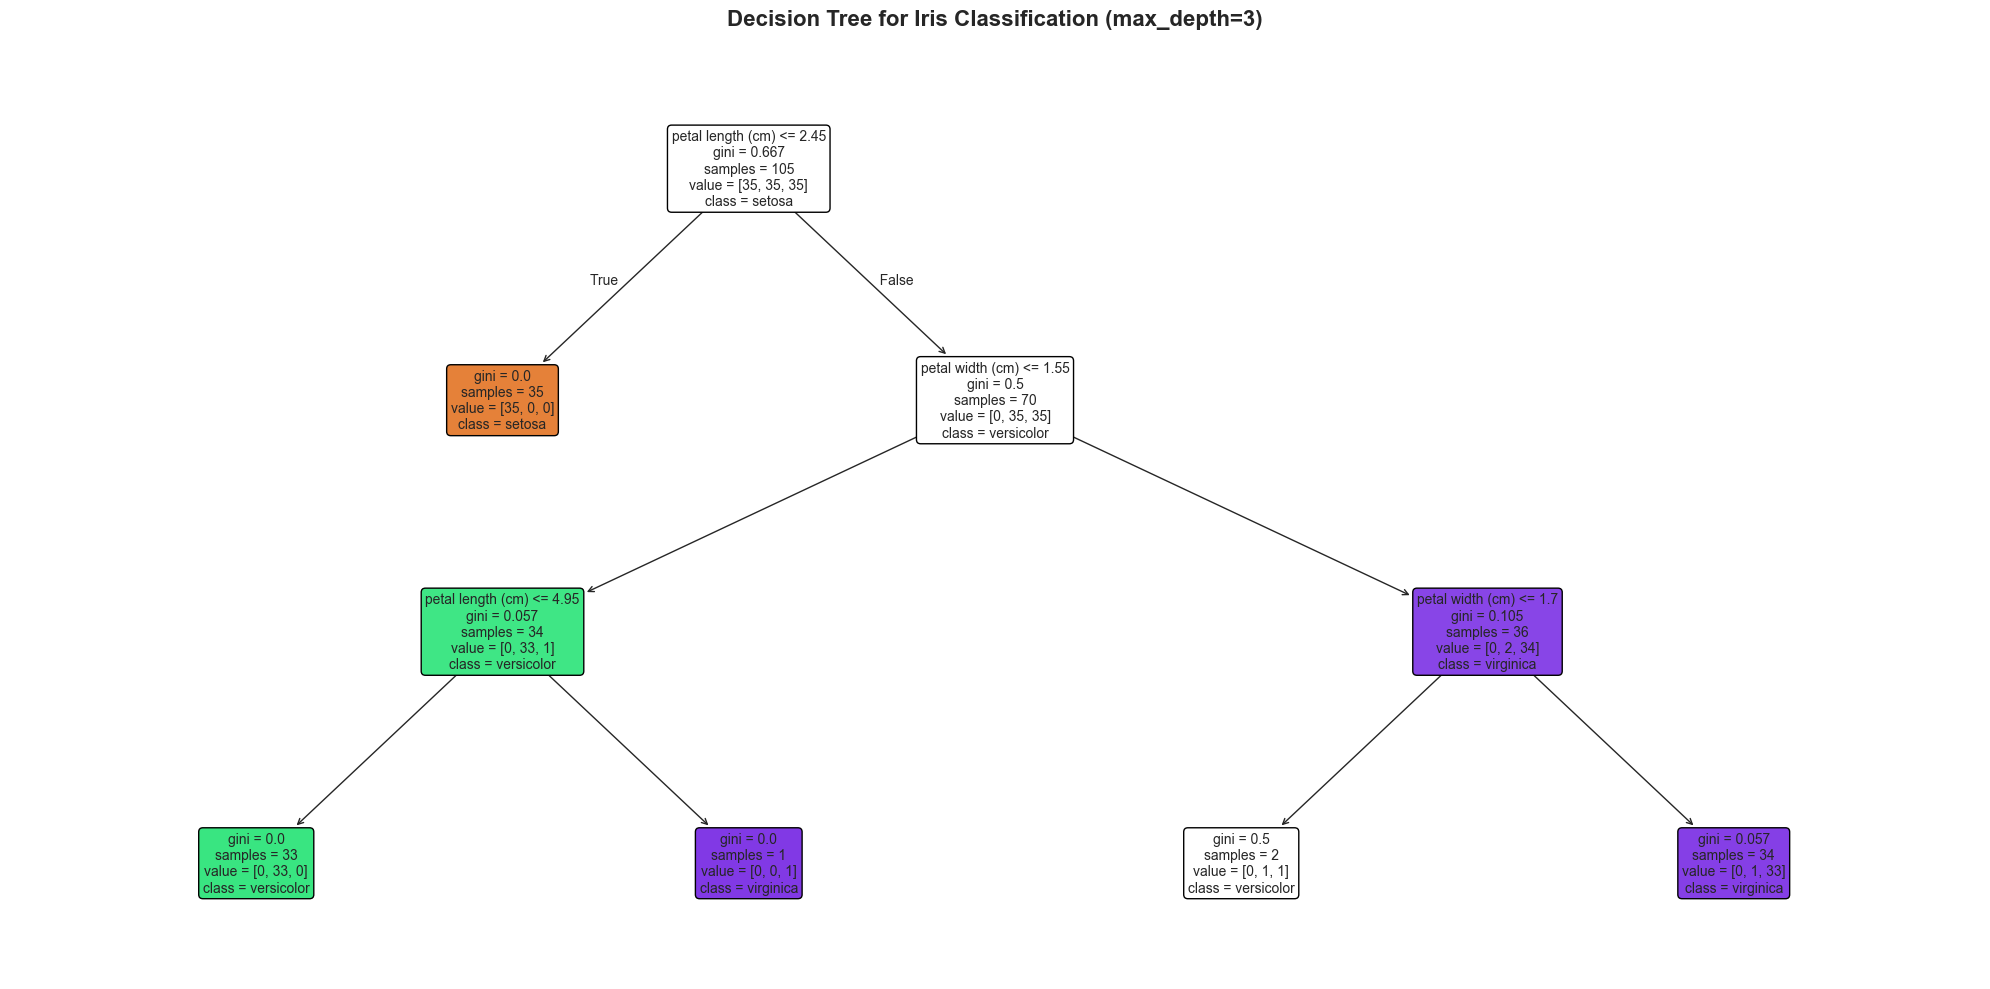


🔍 How to Read This Tree:
  • Each box is a node
  • Top line: splitting criterion (feature ≤ threshold)
  • 'gini': impurity measure (0 = pure, 0.5 = mixed)
  • 'samples': number of training samples at this node
  • 'value': [class 0 count, class 1 count, class 2 count]
  • 'class': predicted class (majority)
  • Color intensity: confidence (darker = more certain)


In [6]:
# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(tree_shallow, 
         feature_names=iris.feature_names,
         class_names=iris.target_names,
         filled=True,
         rounded=True,
         fontsize=10)
plt.title('Decision Tree for Iris Classification (max_depth=3)', 
         fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n🔍 How to Read This Tree:")
print("  • Each box is a node")
print("  • Top line: splitting criterion (feature ≤ threshold)")
print("  • 'gini': impurity measure (0 = pure, 0.5 = mixed)")
print("  • 'samples': number of training samples at this node")
print("  • 'value': [class 0 count, class 1 count, class 2 count]")
print("  • 'class': predicted class (majority)")
print("  • Color intensity: confidence (darker = more certain)")

Note that decision trees can also be used to perform preliminary feature importance analysis. This tree, for instance, tells us that petal length appears more discriminative than petal width for classifying iris species.

## Feature Importance

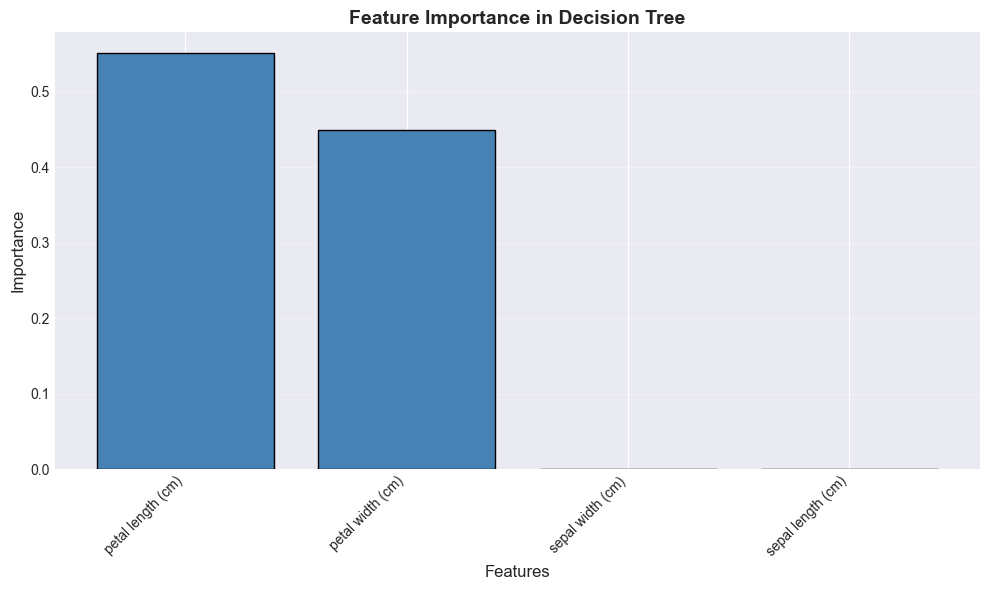


📊 Feature Importance Analysis:
  petal length (cm): 0.5509
  petal width (cm): 0.4491
  sepal width (cm): 0.0000
  sepal length (cm): 0.0000

💡 Importance is based on total reduction in impurity from splits using each feature


In [7]:
# Feature importance from our iris tree
importances = tree_shallow.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(X.shape[1]), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(X.shape[1]), [iris.feature_names[i] for i in indices], rotation=45, ha='right')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Importance', fontsize=12)
plt.title('Feature Importance in Decision Tree', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Analysis:")
for idx in indices:
    print(f"  {iris.feature_names[idx]}: {importances[idx]:.4f}")

print("\n💡 Importance is based on total reduction in impurity from splits using each feature")

## The Overfitting Problem

Decision trees are prone to **overfitting**, they can easily memorize the training data by growing very deep trees that capture noise rather than true patterns.

### Why Trees Overfit
- Without constraints, a tree can keep splitting until every leaf contains just one sample
- Such a tree has perfect training accuracy but generalizes poorly
- Trees have **high variance**: small changes in training data can produce very different trees

In [8]:
# Demonstrate overfitting: unrestricted tree vs pruned tree
tree_overfit = DecisionTreeClassifier(random_state=42)  # No limits!
tree_overfit.fit(X_train, y_train)

print("🌲 Tree Comparison (Iris dataset)")
print("="*60)
print("\nUnrestricted Tree:")
print(f"  Training accuracy: {tree_overfit.score(X_train, y_train):.4f}")
print(f"  Test accuracy:     {tree_overfit.score(X_test, y_test):.4f}")
print(f"  Tree depth:        {tree_overfit.get_depth()}")
print(f"  Number of leaves:  {tree_overfit.get_n_leaves()}")

print("\nPruned Tree (max_depth=3):")
print(f"  Training accuracy: {tree_shallow.score(X_train, y_train):.4f}")
print(f"  Test accuracy:     {tree_shallow.score(X_test, y_test):.4f}")
print(f"  Tree depth:        {tree_shallow.get_depth()}")
print(f"  Number of leaves:  {tree_shallow.get_n_leaves()}")

print("\n⚠️ The unrestricted tree perfectly fits training data but may generalize worse!")

🌲 Tree Comparison (Iris dataset)

Unrestricted Tree:
  Training accuracy: 1.0000
  Test accuracy:     0.9333
  Tree depth:        5
  Number of leaves:  8

Pruned Tree (max_depth=3):
  Training accuracy: 0.9810
  Test accuracy:     0.9778
  Tree depth:        3
  Number of leaves:  5

⚠️ The unrestricted tree perfectly fits training data but may generalize worse!


## Controlling Tree Complexity

### Pre-Pruning (Early Stopping)
Stop growing the tree before it becomes too complex:
- `max_depth`: Maximum depth of the tree
- `min_samples_split`: Minimum samples required to split a node
- `min_samples_leaf`: Minimum samples required in each leaf
- `max_leaf_nodes`: Maximum number of leaf nodes

### Post-Pruning
Grow the full tree, then remove branches that don't improve validation performance:
- **Cost-complexity pruning** (`ccp_alpha` in scikit-learn)
- **Reduced error pruning**: Replace subtrees with leaves if accuracy doesn't decrease

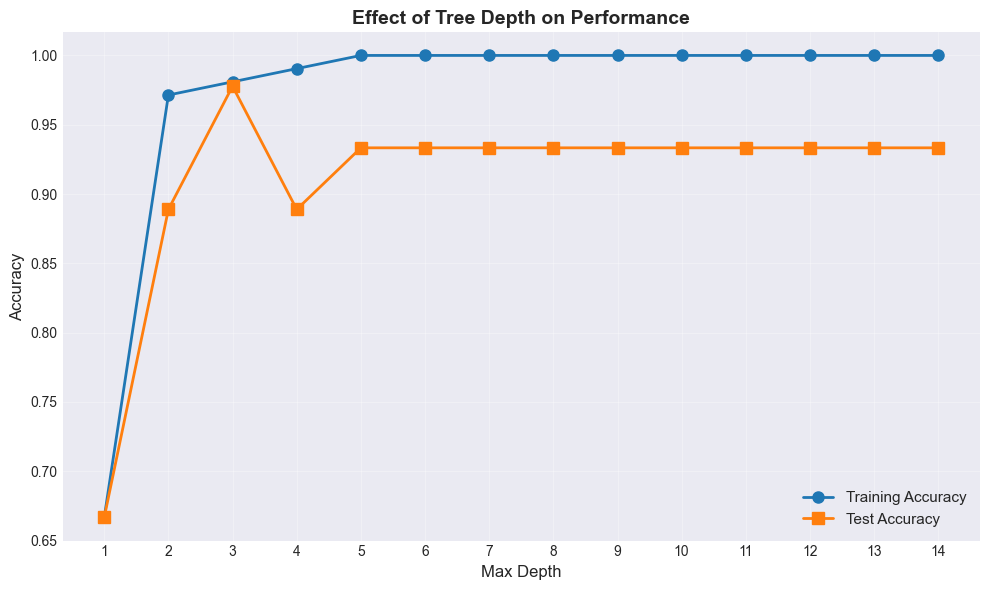


📈 Key Observation:
   Training accuracy increases with depth (can memorize more)
   Test accuracy plateaus or decreases (overfitting kicks in)

   Optimal depth for this dataset: 3


In [9]:
# Effect of max_depth on train/test accuracy
depths = range(1, 15)
train_scores = []
test_scores = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    train_scores.append(tree.score(X_train, y_train))
    test_scores.append(tree.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(depths, train_scores, 'o-', label='Training Accuracy', linewidth=2, markersize=8)
plt.plot(depths, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xlabel('Max Depth', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Effect of Tree Depth on Performance', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.xticks(depths)
plt.tight_layout()
plt.show()

print("\n📈 Key Observation:")
print("   Training accuracy increases with depth (can memorize more)")
print("   Test accuracy plateaus or decreases (overfitting kicks in)")
print(f"\n   Optimal depth for this dataset: {depths[np.argmax(test_scores)]}")

## Decision Boundaries Visualization

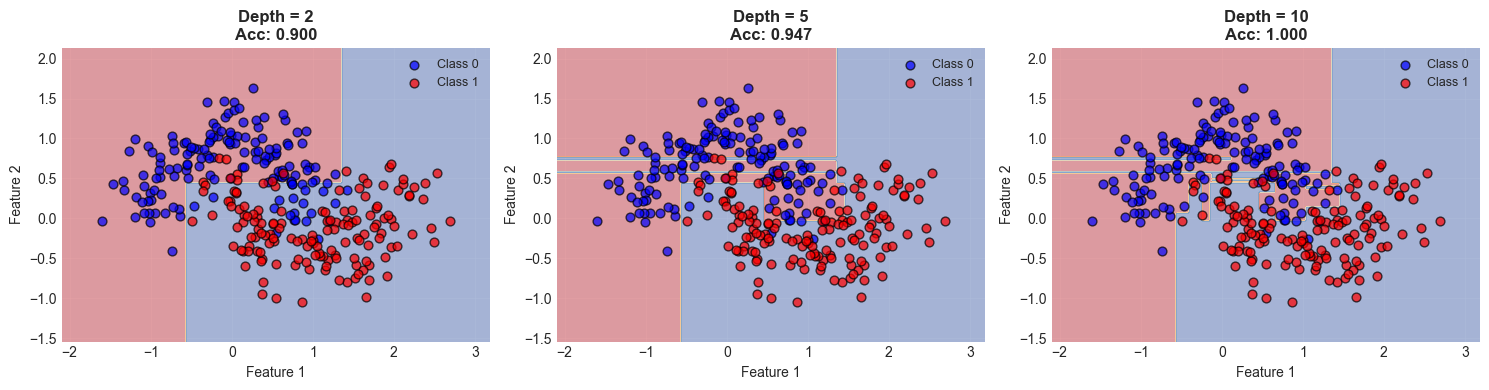


📊 Decision Boundaries:
  • Notice how boundaries are axis-aligned rectangles
  • Deeper trees create more complex boundaries
  • Too deep = overfitting to noise!


In [12]:
# Create 2D dataset for visualization
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=300, noise=0.25, random_state=42)

# Train trees with different depths
depths_viz = [2, 5, 10]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, depth in enumerate(depths_viz):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_moons, y_moons)
    
    # Decision boundary
    ax = axes[idx]
    h = 0.02
    x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
    y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
    ax.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1],
              c='blue', s=40, alpha=0.7, edgecolors='k', label='Class 0')
    ax.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1],
              c='red', s=40, alpha=0.7, edgecolors='k', label='Class 1')
    
    ax.set_title(f'Depth = {depth}\nAcc: {tree.score(X_moons, y_moons):.3f}',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1', fontsize=10)
    ax.set_ylabel('Feature 2', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Decision Boundaries:")
print("  • Notice how boundaries are axis-aligned rectangles")
print("  • Deeper trees create more complex boundaries")
print("  • Too deep = overfitting to noise!")

## Summary

### Key Concepts

1. **Decision trees** create interpretable models through hierarchical if-then rules

2. **Structure:**
   - Root node at top
   - Internal nodes test features against thresholds
   - Leaf nodes contain predictions
   - Binary splits are most common

3. **Building trees** requires greedy algorithms since optimal tree finding is NP-complete

4. **Split quality metrics:**
   - **Entropy** measures information disorder
   - **Gini index** measures misclassification probability
   - **Information gain** = reduction in impurity from a split

5. **Overfitting** is a major concern:
   - Trees have high variance
   - Can memorize training data
   - Solution: pruning and regularization

6. **Complexity control:**
   - Pre-pruning: `max_depth`, `min_samples_split`, `min_samples_leaf`
   - Post-pruning: cost-complexity pruning

7. **Versatility:**
   - Classification and regression
   - No feature scaling needed
   - Handles mixed data types

8. **Feature importance** quantifies each feature's contribution to predictions

9. **Decision boundaries** are axis-aligned (rectangular regions)

---

## Strengths 

- **Interpretable** - easy to visualize and explain
- **No preprocessing** - works with raw, unscaled data
- **Fast inference** - just traverse the tree
- **Captures non-linearity** naturally
- **Built-in feature importance**
- **Handles heterogeneous data** (numerical + categorical)

## Limitations 

- **High variance** - sensitive to training data
- **Overfitting prone** - especially deep trees
- **Greedy optimization** - may miss global optimum
- **Instability** - small data changes can yield different trees
- **Bias with imbalanced classes**
- **Axis-aligned splits** - struggles with diagonal boundaries

## When to Use Decision Trees

 **Good for:**
- Explainability requirements
- Mixed feature types
- Non-linear relationships
- Feature importance analysis
- Quick baseline models

 **Consider alternatives for:**
- High-dimensional data
- Stability requirements
- Small datasets
- Diagonal decision boundaries

**Pro Tip:** Single decision trees often serve as base learners in **ensemble methods** (Random Forests, Gradient Boosting) which address many variance issues while retaining interpretability!